In [2]:
import numpy as np
import pandas as pd
df = pd.read_excel('heart_disease.xlsx')
df

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [3]:
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [54]:
ExcelTable = pd.ExcelFile('heart_disease.xlsx')
Context = pd.read_excel(ExcelTable, 'Description')
df = pd.read_excel(ExcelTable, 'Heart_disease')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
df.shape

(908, 13)

In [8]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [9]:
len(df)

908

In [10]:
len(df.columns)

13

In [11]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].mean())

In [12]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

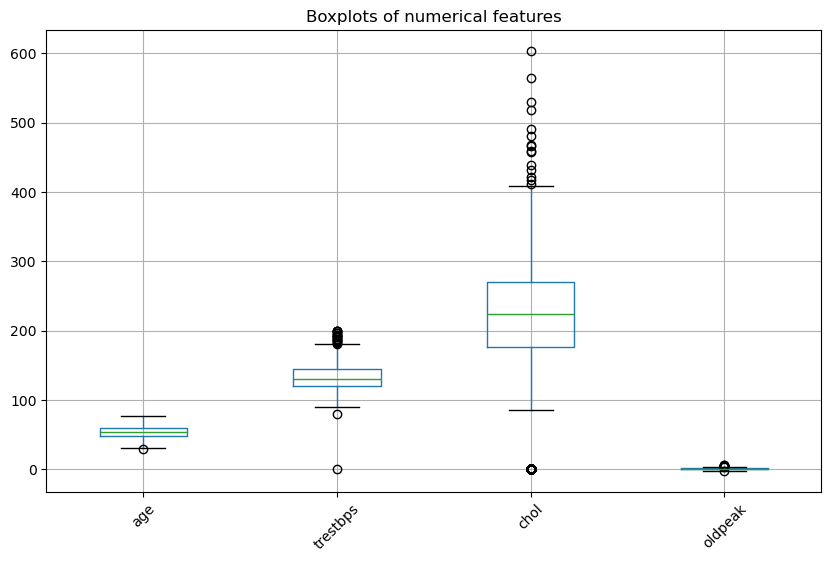

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = ['age', 'trestbps', 'chol', 'oldpeak']
plt.figure(figsize=(10, 6))
df[numeric_cols].boxplot()
plt.title("Boxplots of numerical features")
plt.xticks(rotation=45)
plt.show()

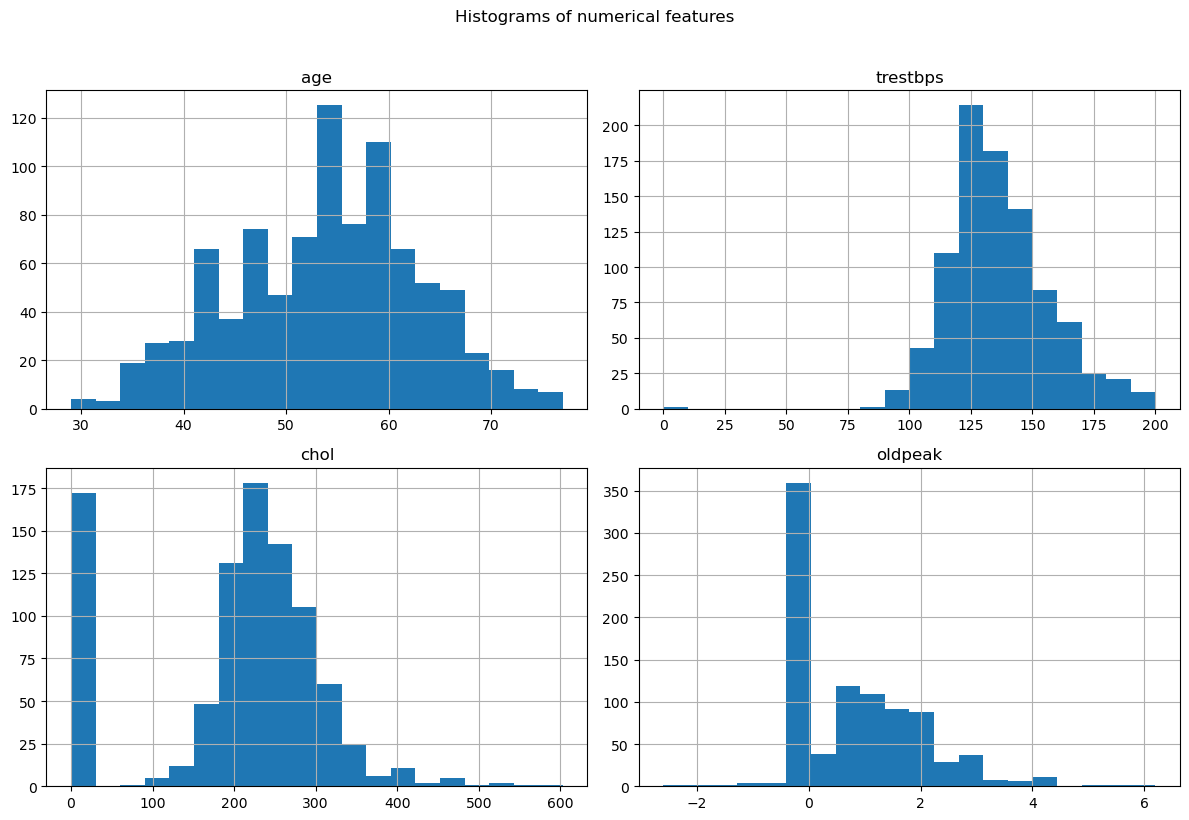

In [14]:
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Histograms of numerical features", y=1.02)
plt.tight_layout()
plt.show()

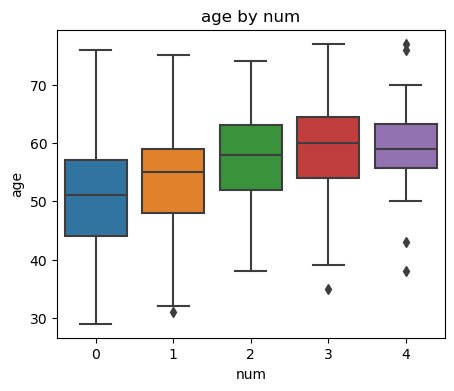

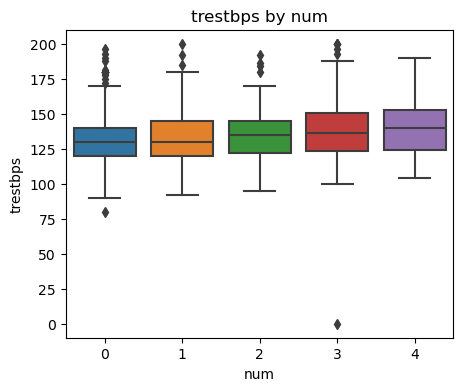

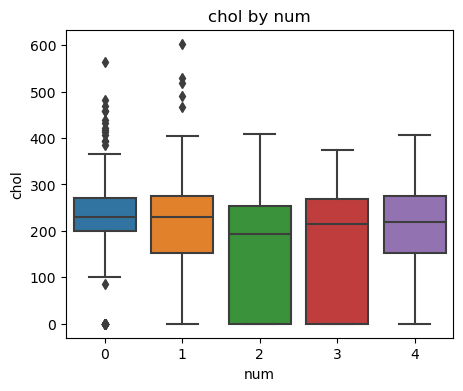

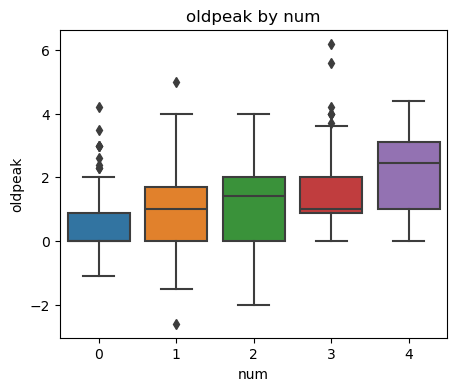

In [15]:
target_col = 'num' 

for col in numeric_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} by {target_col}")
    plt.show()

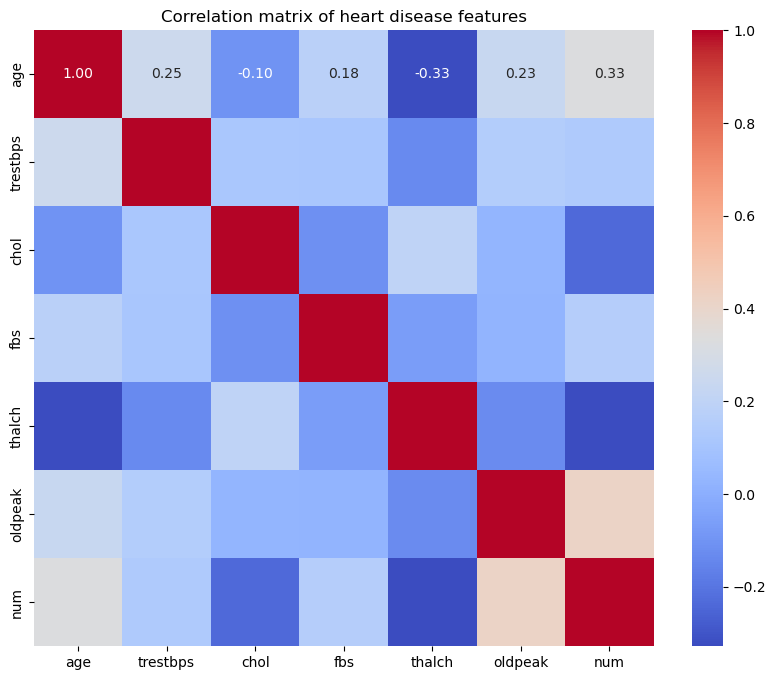

In [16]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix of heart disease features")
plt.show()

In [51]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['exang'] = df['exang'].astype(str).str.upper().replace({'TURE': 'TRUE'})
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

y_pred_base = base_model.predict(X_test)
print("--- Baseline Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(classification_report(y_test, y_pred_base))

--- Baseline Model Performance ---
Accuracy: 0.4670
              precision    recall  f1-score   support

           0       0.70      0.62      0.66        80
           1       0.43      0.43      0.43        53
           2       0.21      0.27      0.24        22
           3       0.29      0.29      0.29        21
           4       0.00      0.00      0.00         6

    accuracy                           0.47       182
   macro avg       0.33      0.32      0.32       182
weighted avg       0.49      0.47      0.48       182



In [52]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,            
    scoring='accuracy',
    n_jobs=-1        
)
grid_search.fit(X_train, y_train)
print("--- Optimized Model (After Tuning) ---")
print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))

--- Optimized Model (After Tuning) ---
Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Test Accuracy: 0.5165
              precision    recall  f1-score   support

           0       0.70      0.78      0.73        80
           1       0.40      0.58      0.47        53
           2       0.00      0.00      0.00        22
           3       1.00      0.05      0.09        21
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.42      0.28      0.26       182
weighted avg       0.54      0.52      0.47       182



C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\amarm\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


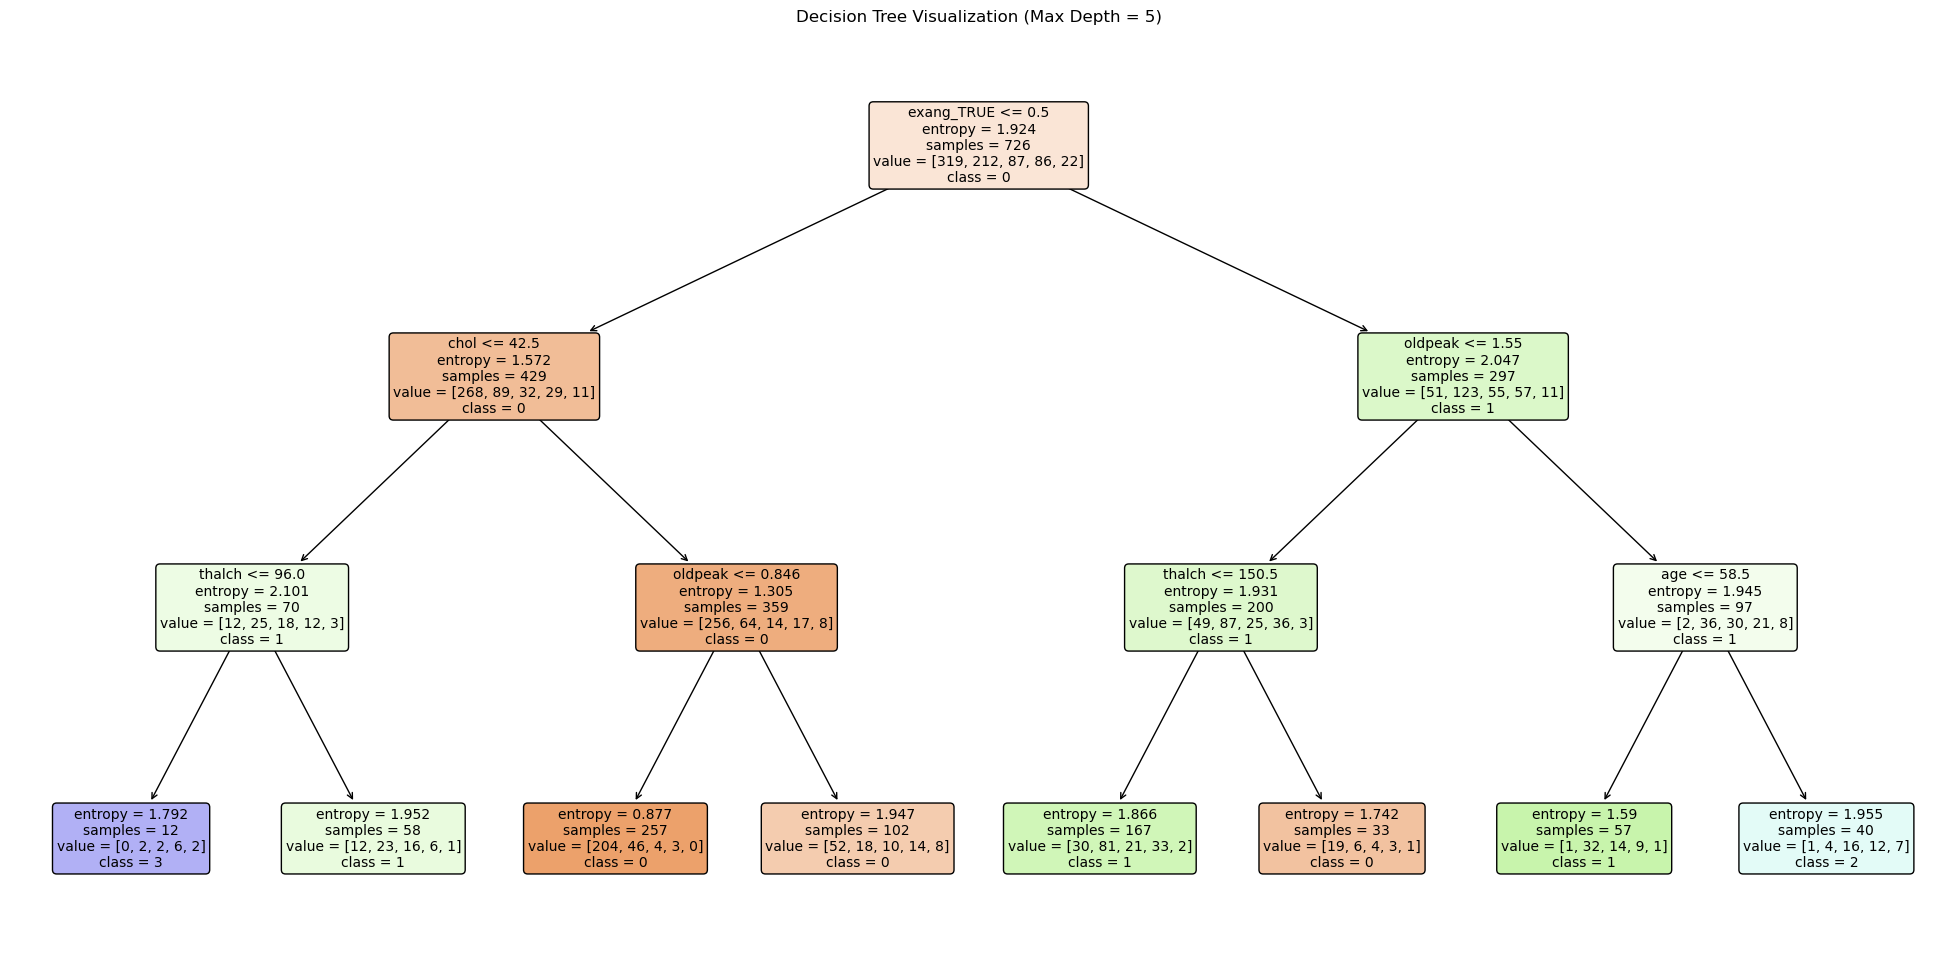

In [53]:
plt.figure(figsize=(25, 12))
plot_tree(best_model, 
          feature_names=X.columns.tolist(), 
          class_names=[str(i) for i in sorted(y.unique())], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Visualization (Max Depth = 5)")
plt.savefig('decision_tree_structure.png')

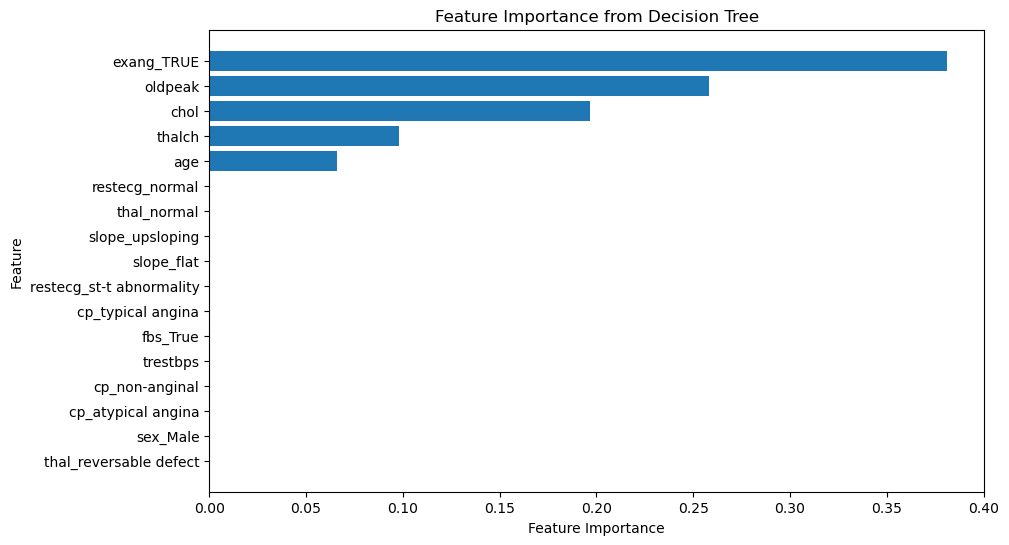

Feature Importance Table:
                     Feature  Importance
12                exang_TRUE    0.381167
4                    oldpeak    0.258093
2                       chol    0.196868
3                     thalch    0.097983
0                        age    0.065889
10            restecg_normal    0.000000
15               thal_normal    0.000000
14           slope_upsloping    0.000000
13                slope_flat    0.000000
11  restecg_st-t abnormality    0.000000
8          cp_typical angina    0.000000
9                   fbs_True    0.000000
1                   trestbps    0.000000
7             cp_non-anginal    0.000000
6         cp_atypical angina    0.000000
5                   sex_Male    0.000000
16    thal_reversable defect    0.000000


In [35]:
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance from Decision Tree")
plt.gca().invert_yaxis() 
plt.savefig('feature_importance.png')
plt.show()
print("Feature Importance Table:")
print(feature_importance_df)

1.
max_depth: Controls how deep the tree grows. Deeper trees capture more detail (high variance/overfitting), while shallower trees are simpler (high bias/underfitting).
min_samples_split: The minimum samples required to split a node. Higher values prevent the model from learning rules based on very few data points.
criterion: The function to measure split quality (Gini for speed, Entropy for information gain).
min_samples_leaf: The minimum samples required at a leaf node. Higher values smooth the model, preventing it from being overly sensitive to outliers.

2.Differences betweeen the One-Hot-Encoding and label-Encoding is :
->In one Hot Encoding the data is transformed into only yes or no type and the data takes only two variables.
->In Label Encoding the data is used multiple columns to convert the data into all equal type or similar.